## Testing preprocessing

In [2]:
import temporian as tp
import pandas as pd
import numpy as np
from datetime import datetime
import os
from tqdm.auto import tqdm
print(os.getcwd())
import TFRecorder

/mnt/c/Users/Alexander/PycharmProjects/levbot/Data


2025-02-06 00:37:22.186185: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-06 00:37:22.289890: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-06 00:37:22.356539: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738798642.398948   41005 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738798642.411305   41005 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-06 00:37:22.567927: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [41]:
import TFRecorder

ts = 1597142100
CG = TFRecorder.coinRecordGenerator("BTCUSD_PERP")
CG.loadData("klines", "1m")

  0%|          | 0/54 [00:00<?, ?it/s]

timestamp,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy asset volume,Taker buy quote asset volume
2020-08-11 07:03:59.999000+00:00,1.178e+04,1.178e+04,1.178e+04,1.178e+04,0,0,0,0,0
2020-08-11 07:04:59.999000+00:00,1.178e+04,1.178e+04,1.178e+04,1.178e+04,0,0,0,0,0
2020-08-11 07:05:59.999000+00:00,1.178e+04,1.178e+04,1.178e+04,1.178e+04,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…
2025-01-31 23:57:59.999000+00:00,1.023e+05,1.024e+05,1.023e+05,1.023e+05,20146,19.68,327,15390,15.04
2025-01-31 23:58:59.999000+00:00,1.023e+05,1.023e+05,1.023e+05,1.023e+05,954,0.9323,49,917,0.8962
2025-01-31 23:59:59.999000+00:00,1.023e+05,1.023e+05,1.023e+05,1.023e+05,7448,7.279,218,2183,2.133


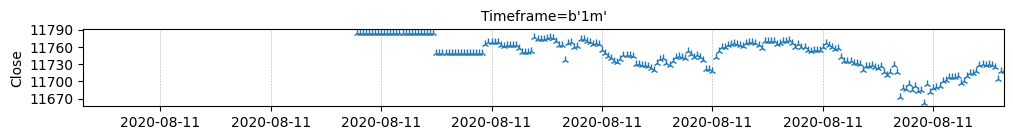

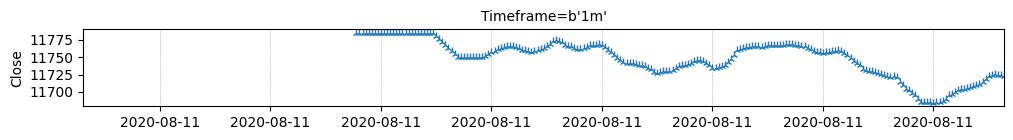

In [45]:
#CG.evset.plot(min_time = ts - 30*600, max_time = ts)
close = CG.evset["Close"]
sma = close.simple_moving_average(tp.duration.minutes(1)* 7.8)
close.plot(min_time = ts - 30*600, max_time = ts)
sma.plot(min_time = ts - 30*600, max_time = ts)

### Format and save as tfdata

In [4]:
CG.save()
